In [ ]:
Sales Performance Analysis Using (Python Liberary's : Pandas ,Matplotlib and Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"data\Sales-Superstore-Dataset.csv",encoding='latin1')
df.head()

,Category,City,Country,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,...,State,Sub-Category,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales,Discounted Profit,Profit From Sales w/o discount
0,Office Supplies,Houston,United States,Darren Powers,Message Book,04-01-2011,CA-2011-103800,77095.0,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Central,...,Texas,Paper,20%,1.0,$6,34%,2.0,$16,6.0,0.0
1,Office Supplies,Naperville,United States,Phillina Ober,GBC,05-01-2011,CA-2011-112326,60540.0,GBC Standard Plastic Binding Systems Combs,Central,...,Illinois,Binders,80%,1.0,($5),-155%,2.0,$4,-5.0,0.0
2,Office Supplies,Naperville,United States,Phillina Ober,Avery,05-01-2011,CA-2011-112326,60540.0,Avery 508,Central,...,Illinois,Labels,20%,1.0,$4,36%,3.0,$12,4.0,0.0
3,Office Supplies,Naperville,United States,Phillina Ober,SAFCO,05-01-2011,CA-2011-112326,60540.0,SAFCO Boltless Steel Shelving,Central,...,Illinois,Storage,20%,1.0,($65),-24%,3.0,$273,-65.0,0.0
4,Office Supplies,Philadelphia,United States,Mick Brown,Avery,06-01-2011,CA-2011-141817,19143.0,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,...,Pennsylvania,Art,20%,1.0,$5,25%,3.0,$20,5.0,0.0


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Category                         9994 non-null   str    
 1   City                             9994 non-null   str    
 2   Country                          9994 non-null   str    
 3   Customer Name                    9994 non-null   str    
 4   Manufacturer                     9994 non-null   str    
 5   Order Date                       9994 non-null   str    
 6   Order ID                         9994 non-null   str    
 7   Postal Code                      9994 non-null   float64
 8   Product Name                     9994 non-null   str    
 9   Region                           9994 non-null   str    
 10  Segment                          9994 non-null   str    
 11  Ship Date                        9994 non-null   str    
 12  Ship Mode                      

Category                           1
City                               1
Country                            1
Customer Name                      1
Manufacturer                       1
Order Date                         1
Order ID                           1
Postal Code                        1
Product Name                       1
Region                             1
Segment                            1
Ship Date                          1
Ship Mode                          1
State                              1
Sub-Category                       1
Discount                           1
Number of Records                  1
Profit                             1
Profit Ratio                       1
Quantity                           1
Sales                              1
Discounted Profit                  1
Profit  From Sales w/o discount    1
dtype: int64

In [5]:
df[df['Category'].isnull()]

,Category,City,Country,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,...,State,Sub-Category,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales,Discounted Profit,Profit From Sales w/o discount
9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df=df.dropna()

In [9]:
df.shape

(9994, 23)

In [18]:
df['Sales'] = df['Sales'].str.replace('$','',regex = False).str.replace(',','',regex = False).astype(float)
df['Profit'] = df['Profit'].str.replace('$','',regex= False).str.replace(',','',regex = False).str.replace('(','-',regex =False).str.replace(')','',regex = False).astype(float)

In [20]:

df['Profit']

0        6.0
1       -5.0
2        4.0
3      -65.0
4        5.0
        ... 
9989    -1.0
9990     5.0
9991     6.0
9992     3.0
9993    57.0
Name: Profit, Length: 9994, dtype: float64

In [22]:
df['Discount'] = df['Discount'].str.replace('%','',regex= False).astype(float) / 100
df['Profit Ratio'] = df['Profit Ratio'].str.replace('%','',regex= False).astype(float) /100

In [23]:
df.info

<bound method DataFrame.info of              Category           City        Country      Customer Name  \
0     Office Supplies        Houston  United States      Darren Powers   
1     Office Supplies     Naperville  United States      Phillina Ober   
2     Office Supplies     Naperville  United States      Phillina Ober   
3     Office Supplies     Naperville  United States      Phillina Ober   
4     Office Supplies   Philadelphia  United States         Mick Brown   
...               ...            ...            ...                ...   
9989  Office Supplies       Loveland  United States      Jill Matthias   
9990  Office Supplies      Fairfield  United States         Erica Bern   
9991  Office Supplies      Fairfield  United States         Erica Bern   
9992       Technology  New York City  United States  Patrick O'Donnell   
9993  Office Supplies       Columbus  United States        Chuck Clark   

      Manufacturer  Order Date        Order ID  Postal Code  \
0     Message Bo

In [27]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format = '%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format = '%d-%m-%Y')

In [29]:
df.info

<bound method DataFrame.info of              Category           City        Country      Customer Name  \
0     Office Supplies        Houston  United States      Darren Powers   
1     Office Supplies     Naperville  United States      Phillina Ober   
2     Office Supplies     Naperville  United States      Phillina Ober   
3     Office Supplies     Naperville  United States      Phillina Ober   
4     Office Supplies   Philadelphia  United States         Mick Brown   
...               ...            ...            ...                ...   
9989  Office Supplies       Loveland  United States      Jill Matthias   
9990  Office Supplies      Fairfield  United States         Erica Bern   
9991  Office Supplies      Fairfield  United States         Erica Bern   
9992       Technology  New York City  United States  Patrick O'Donnell   
9993  Office Supplies       Columbus  United States        Chuck Clark   

      Manufacturer Order Date        Order ID  Postal Code  \
0     Message Boo

In [30]:
df.duplicated().sum()

np.int64(1)

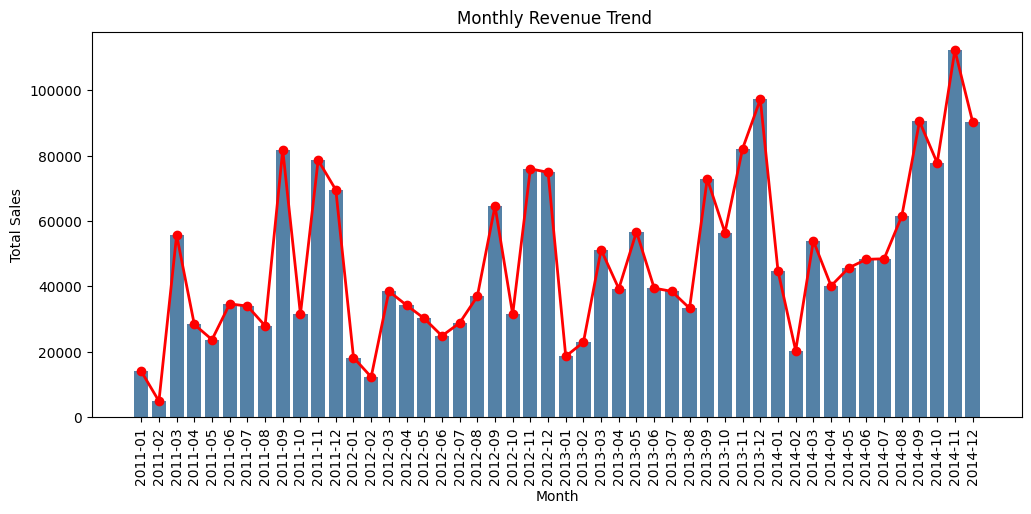

In [33]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

plt.figure(figsize= (12,5))
sns.barplot(data = monthly_sales, x='Order Date',y='Sales',color = 'steelblue')
plt.plot(range(len(monthly_sales)),monthly_sales['Sales'],color = 'red' , marker = 'o',linewidth = 2)
plt.title('Monthly Revenue Trend ')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation = 90)
plt.show()

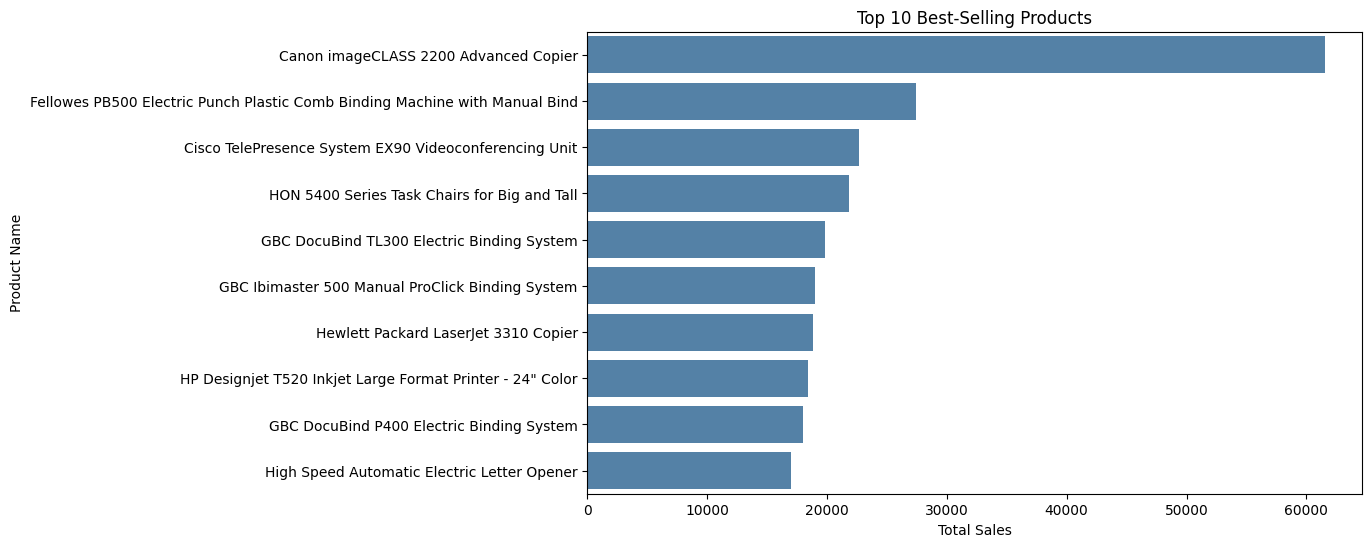

In [36]:
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending = False)
top10 = product_sales.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values ,y=top10.index ,color = 'steelblue')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.show()

In [38]:
top5_sales = product_sales.head(5).sum()
total_sales = product_sales.sum()

top5_pct = (top5_sales / total_sales) * 100
print(f"Top 5 Products Countribute {top5_pct:.1f}% of total revenue")


Top 5 Products Countribute 6.7% of total revenue


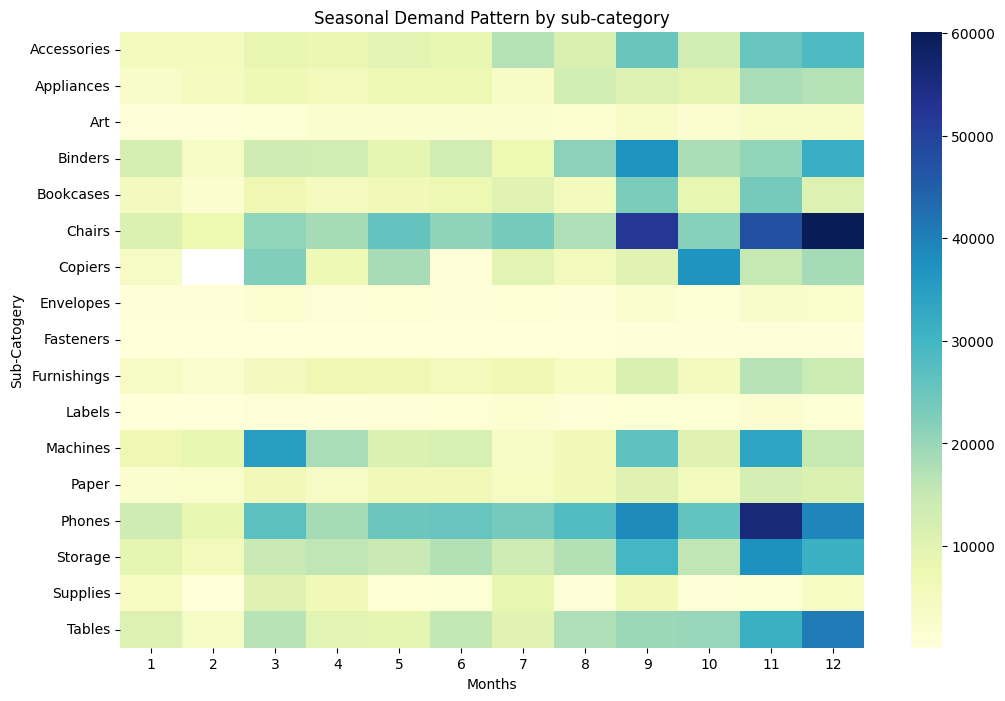

In [49]:
df['Month'] = df['Order Date'].dt.month
heatmap_data = df.pivot_table(index = 'Sub-Category' , columns = 'Month' ,values = 'Sales' , aggfunc = 'sum')

plt.figure(figsize = (12,8))
sns.heatmap(heatmap_data, cmap = 'YlGnBu',annot = False)
plt.title('Seasonal Demand Pattern by sub-category')
plt.xlabel('Months')
plt.ylabel('Sub-Catogery')
plt.show()